In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('clean_data.csv')
display(df.head(10))

,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,1.0,0.0,6.97,28.18,1.0
1,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,32.0,Female,Mobile,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,14.30,79.03,1.0
4,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,56.0,Female,Desktop,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,36.0,Male,Mobile,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,40.0,Female,Mobile,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0
8,28.0,Female,Mobile,10.90,14.0,7.0,9.0,0.0,0.0,1.0,13.80,85.46,1.0
9,28.0,Female,Mobile,9.97,3.0,14.0,8.0,0.0,0.0,0.0,14.12,14.16,1.0


<Axes: >

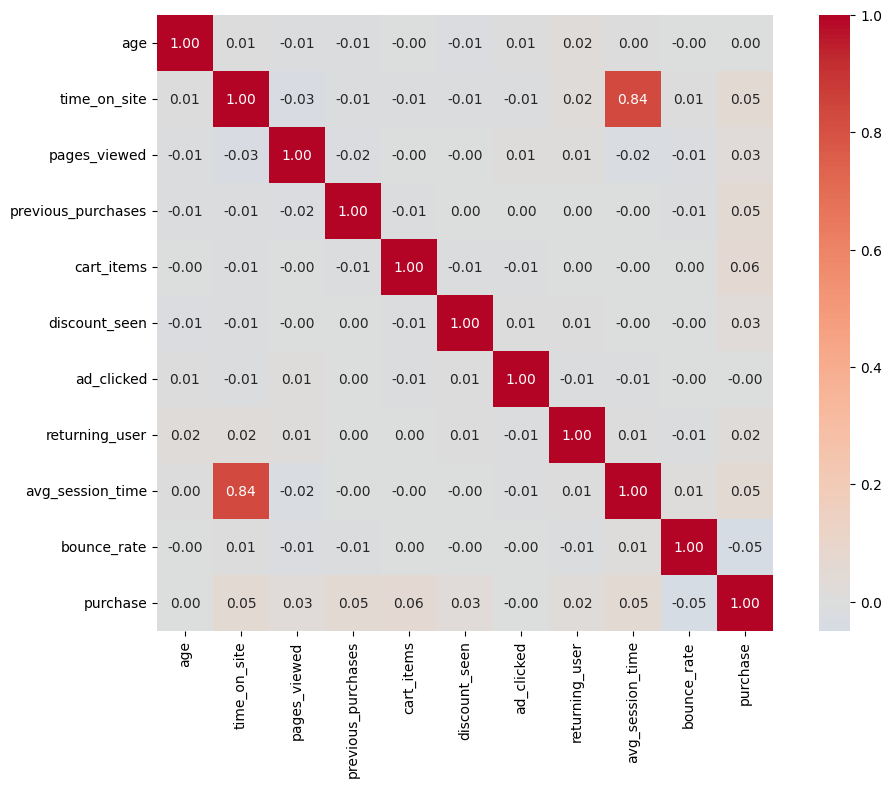

In [3]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(data=numeric_cols.corr() ,annot=True ,cmap='coolwarm' , center=0 , square=True ,  fmt=".2f")

* time_on_site and avg_session_time have a very high correlation (0.84).

* purchase has extremely weak correlations with all features (highest is only 0.06 with cart_items).

* Slightly Important Features<br>
-> cart_items (0.06)<br>
-> previous_purchases (0.05)<br>
-> bounce_rate (-0.05)<br>

1 . What factors most influence whether a user makes a purchase?

* numeric analysis


CORRELATION WITH PURCHASE (Strongest to Weakest)
              Feature  Correlation  P-value
4          cart_items       0.0580   0.0000
1        time_on_site       0.0544   0.0000
3  previous_purchases       0.0531   0.0000
8    avg_session_time       0.0505   0.0000
5       discount_seen       0.0289   0.0096
2        pages_viewed       0.0258   0.0211
7      returning_user       0.0233   0.0372
0                 age       0.0010   0.9285
6          ad_clicked      -0.0021   0.8499
9         bounce_rate      -0.0499   0.0000


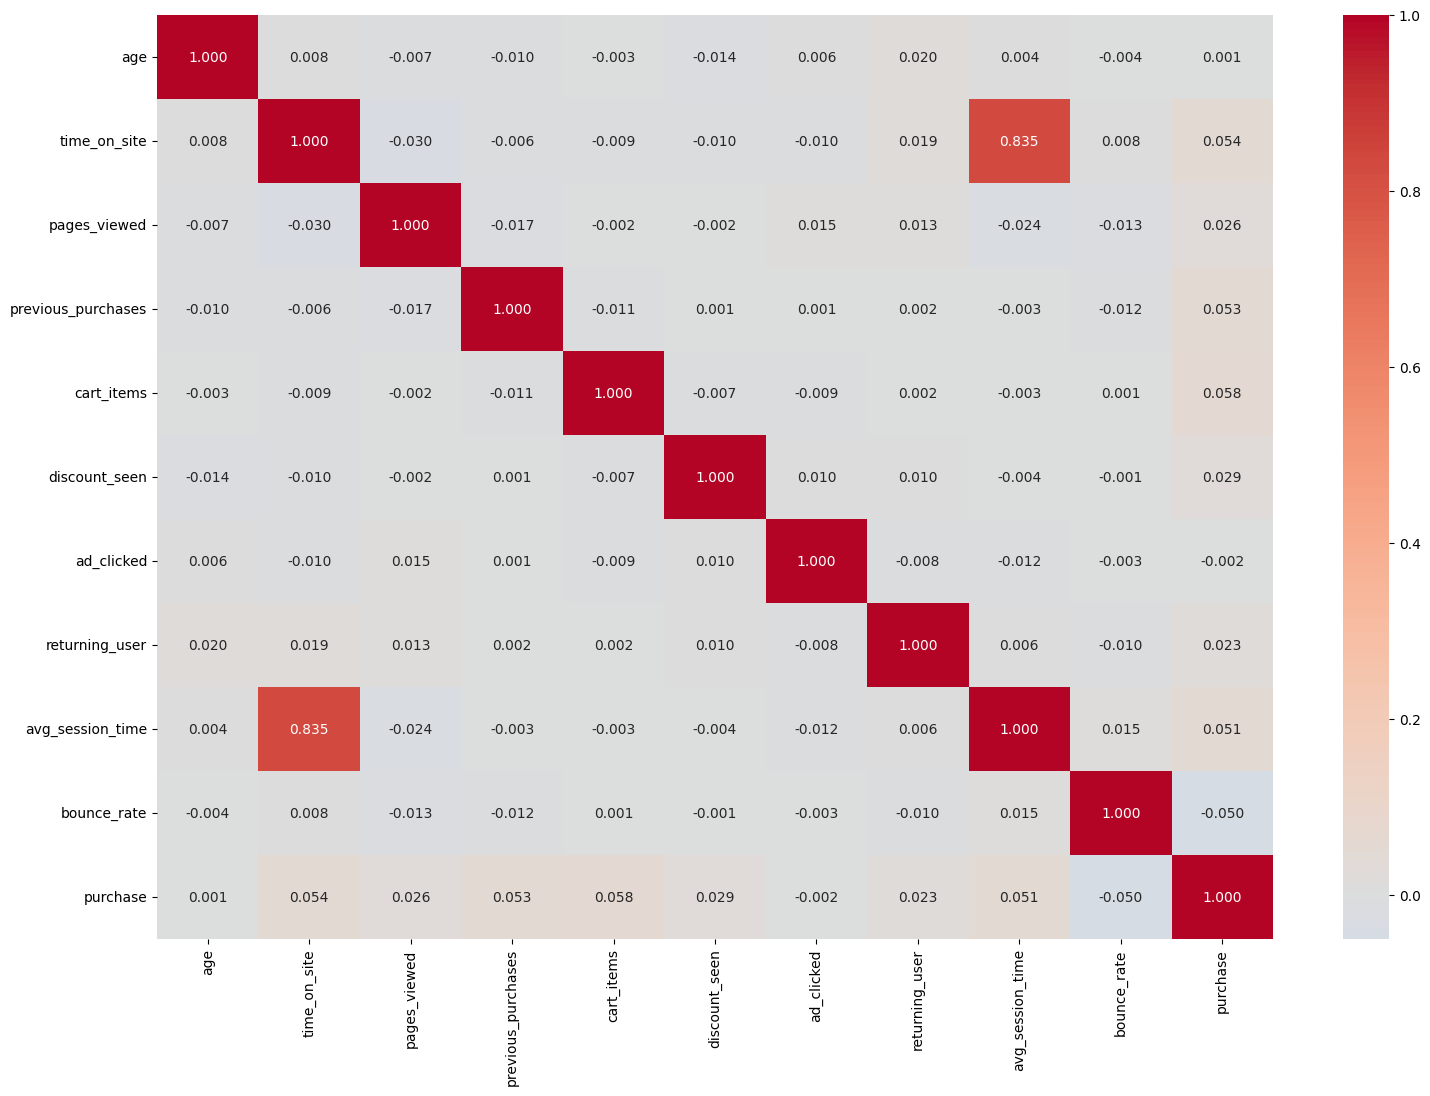

In [4]:
from scipy.stats import pearsonr, chi2_contingency,spearmanr
numeric_binary_cols =['age' , 'time_on_site' , 'pages_viewed','previous_purchases','cart_items','discount_seen','ad_clicked','returning_user','avg_session_time','bounce_rate']

correlations = []
for col in numeric_binary_cols:
    corr, p_value = pearsonr(df[col], df['purchase'])
    correlations.append({
        'Feature': col,
        'Correlation': round(corr, 4),
        'P-value': round(p_value, 4)
    })

corr_df = pd.DataFrame(correlations).sort_values(by='Correlation', ascending=False)

print("\n" + "="*60)
print("CORRELATION WITH PURCHASE (Strongest to Weakest)")
print(corr_df)
plt.figure(figsize=(18, 12))
corr_matrix = df[numeric_binary_cols + ['purchase']].corr()
sns.heatmap(corr_matrix , annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.show()


In [5]:
print('purchase rate by binary features')
df.groupby(['discount_seen','returning_user','ad_clicked']).agg(
    purchase_rate = ('purchase' , 'mean')
)

purchase rate by binary features


purchase_rate
discount_seen returning_user ad_clicked               
0.0           0.0            0.0              0.995722
                             1.0              0.994786
              1.0            0.0              1.000000
                             1.0              0.998037
1.0           0.0            0.0              0.998918
                             1.0              1.000000
              1.0            0.0              0.999053
                             1.0              1.000000

* categorical analysis

In [6]:
print("PURCHASE RATE BY CATEGORICAL FEATURES")
df.groupby(['gender','device_type']).agg(
    purchase_rate = ('purchase' , 'mean')
)

PURCHASE RATE BY CATEGORICAL FEATURES


purchase_rate
gender device_type               
Female Desktop           0.998308
       Mobile            0.997002
       Tablet            0.997449
Male   Desktop           0.999155
       Mobile            0.999203
       Tablet            1.000000

The most influential factors for whether a user makes a purchase are:

* cart_items (strongest positive)<br>
* time_on_site & avg_session_time (engagement)<br>
* previous_purchases (loyalty / habit)<br>


2 . How does user engagement impact conversion rates?


📊 TIME_ON_SITE by Engagement Level:
                     Conversion Rate  count
time_on_site_bucket                        
Very Low                       99.31   1602
Low                            99.94   1598
Medium                         99.94   1603
High                          100.00   1597
Very High                     100.00   1600


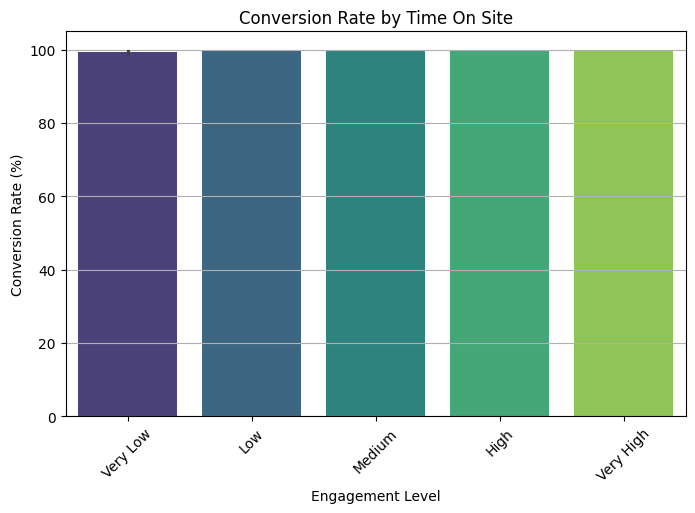


📊 PAGES_VIEWED by Engagement Level:
                     Conversion Rate  count
pages_viewed_bucket                        
Very Low                       99.81   1607
Low                            99.59   1706
Medium                         99.89   1849
High                           99.94   1641
Very High                     100.00   1197


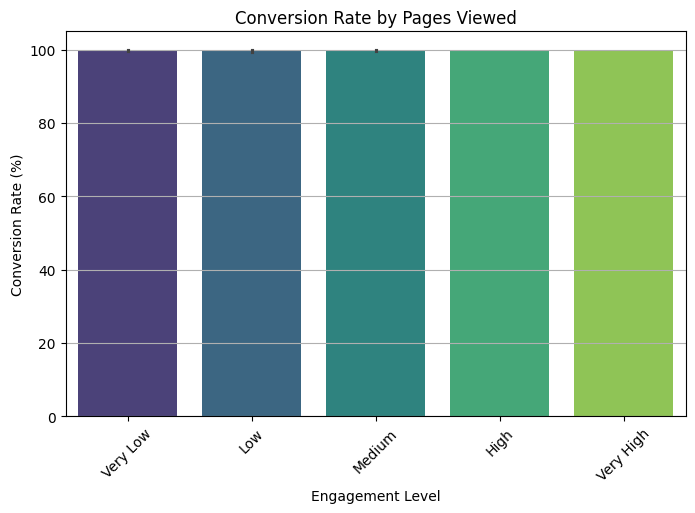


📊 AVG_SESSION_TIME by Engagement Level:
                         Conversion Rate  count
avg_session_time_bucket                        
Very Low                           99.38   1601
Low                                99.81   1602
Medium                            100.00   1597
High                              100.00   1604
Very High                         100.00   1596


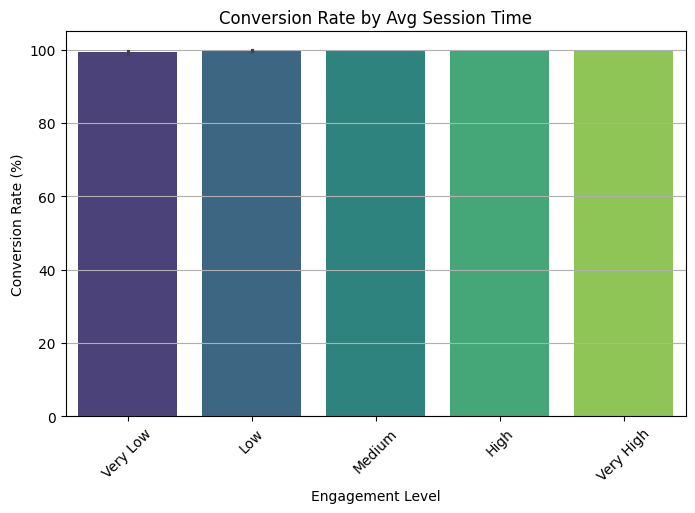


📊 BOUNCE_RATE by Engagement Level:
                    Conversion Rate  count
bounce_rate_bucket                        
Very Low                     100.00   1600
Low                          100.00   1600
Medium                        99.94   1600
High                          99.88   1600
Very High                     99.38   1600


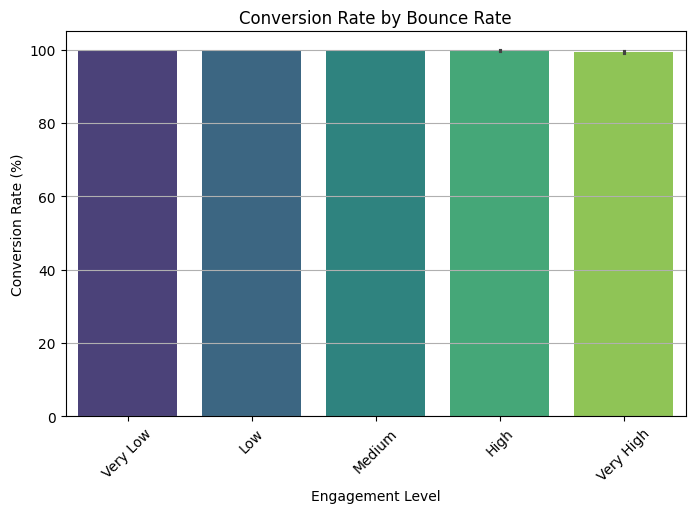


📊 CART_ITEMS by Engagement Level:
                   Conversion Rate  count
cart_items_bucket                        
Very Low                     99.44   2338
Low                         100.00   1528
Medium                      100.00    943
High                        100.00   1615
Very High                   100.00   1576


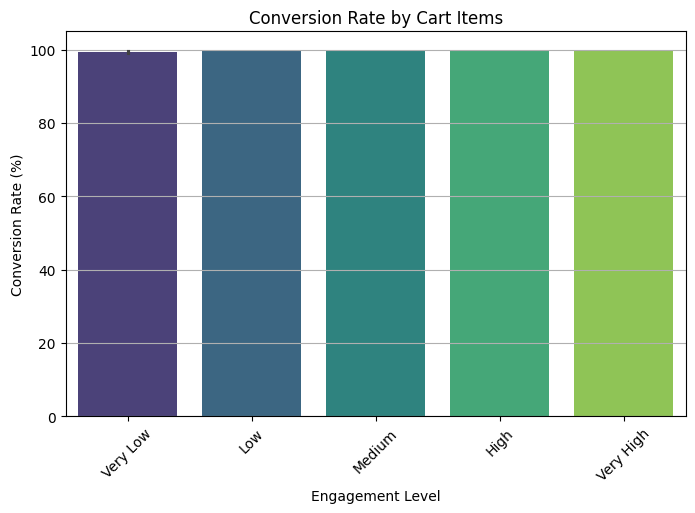

In [9]:
engagement_cols = ['time_on_site', 'pages_viewed', 'avg_session_time', 'bounce_rate', 'cart_items']

for col in engagement_cols:
    # Using qcut for more balanced bins
    df[f'{col}_bucket'] = pd.qcut(df[col], q=5, duplicates='drop', labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

for col in engagement_cols:
    conversion = df.groupby(f'{col}_bucket')['purchase'].agg([
        'mean', 'count'
    ]).rename(columns={'mean': 'Conversion Rate'})

    conversion['Conversion Rate'] = conversion['Conversion Rate'] * 100
    print(f"\n📊 {col.upper()} by Engagement Level:")
    print(conversion.round(2))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=df[f'{col}_bucket'], y=df['purchase']*100, palette='viridis')
    plt.title(f'Conversion Rate by {col.replace("_", " ").title()}')
    plt.ylabel('Conversion Rate (%)')
    plt.xlabel('Engagement Level')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()

* Higher engagement drives conversions: Very High buckets in time_on_site, pages_viewed, avg_session_time, and cart_items consistently hit 100% conversion rates, vs. 99.3-99.9% in low buckets—showing deeper interaction boosts completion.

* Bounce rate anomaly: Surprisingly, Very Low bounce (100%) and Very High (99.38%) both perform well, but medium/high dip slightly; low bounce doesn't guarantee higher conversions here.

* Cart items most reliable: All non-Very Low cart buckets achieve 100%, with larger samples, indicating adding items to cart is the strongest engagement-to-conversion predictor.

3 . How does bounce rate affect purchase probability?

----bounce_rate---------
               mean    min    max
purchase                         
0.0       85.620769  49.50  98.57
1.0       49.857799   0.01  99.97
------corelation---------
corr : -0.04994239130487508 , p_value : 7.855892978009242e-06
---------bounce_bucket-------
                        mean  count  Conversion Rate (%)
bounce_rate_bucket                                      
Very Low            1.000000   1600               100.00
Low                 1.000000   1600               100.00
Medium              0.999375   1600                99.94
High                0.998750   1600                99.88
Very High           0.993750   1600                99.38


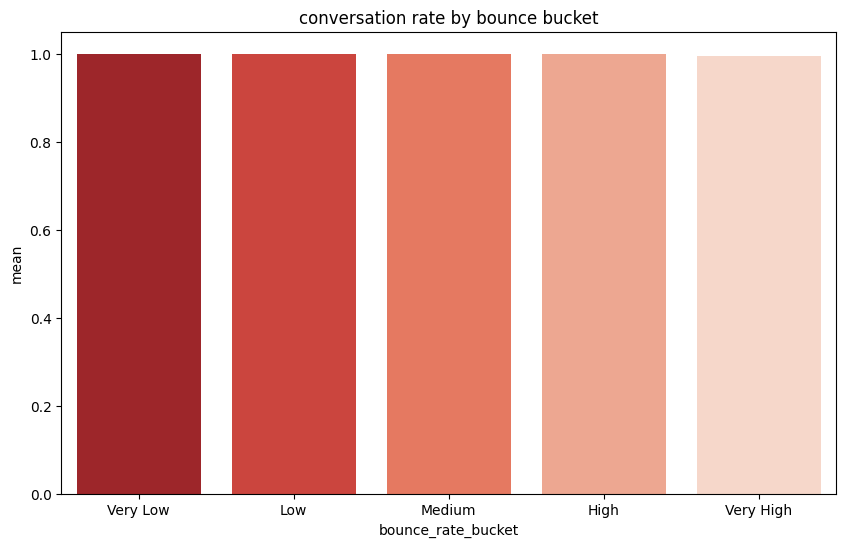

In [11]:
bounce_rate = df.groupby('purchase')['bounce_rate'].agg([
    'mean' , 'min' , 'max'])

print("----bounce_rate---------")
print(bounce_rate)
corr_results = []

pearson_corr, p_value = pearsonr(df['bounce_rate'], df['purchase'])
print("------corelation---------")
print(f"corr : {pearson_corr} , p_value : {p_value}")

conversion_by_bounce = df.groupby('bounce_rate_bucket')['purchase'].agg(['mean' , 'count'])
conversion_by_bounce['Conversion Rate (%)'] = (conversion_by_bounce['mean'] * 100).round(2)
print('---------bounce_bucket-------')
print(conversion_by_bounce)

plt.figure(figsize=(10,6))
sns.barplot(x=conversion_by_bounce.index, 
            y=conversion_by_bounce['mean'], 
            palette='Reds_r')
plt.title('conversation rate by bounce bucket')
plt.show()


• Higher bounce rate is clearly associated with lower purchase probability.<BR>
• Users with **Very High** bounce rate have the lowest conversion.

4 . Do returning users convert more than new users?

,Conversion Rate,Number of Users
returning_user,,
0.0,99.740,3846
1.0,99.928,4154


corelation : 0.023294253764090205 , p_value : 0.03720945015027802 with purchase


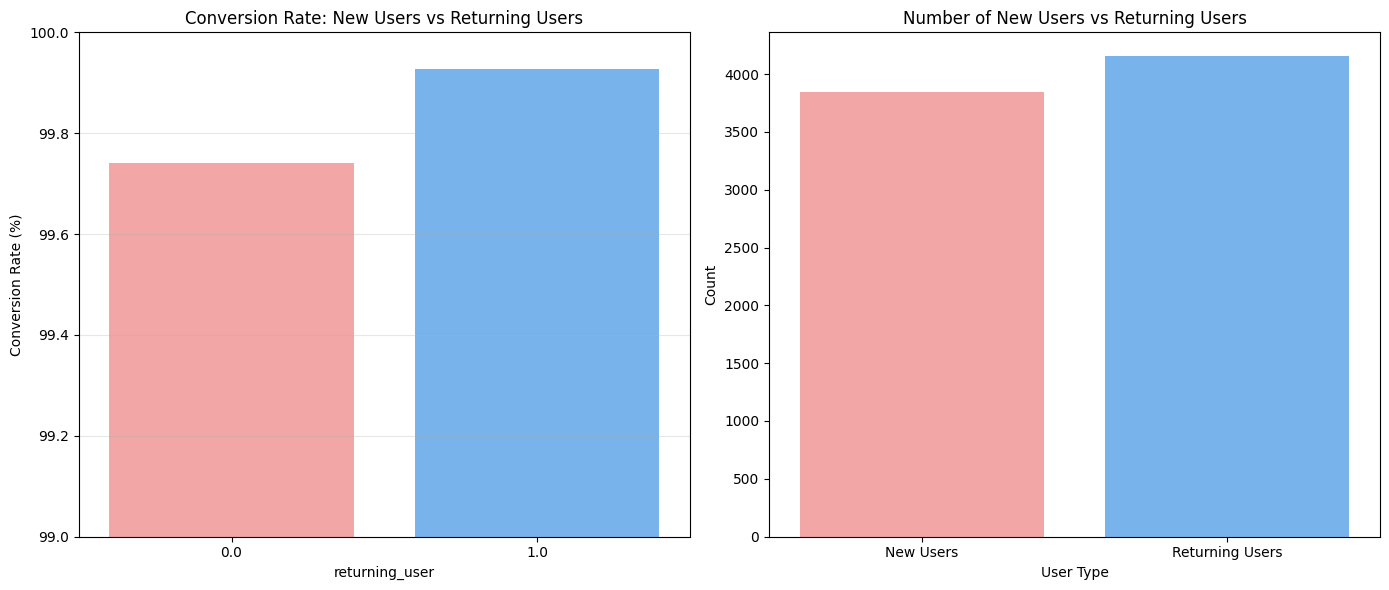

In [57]:
conversion_by_returning = df.groupby('returning_user')['purchase'].agg([
    'mean', 'count'
]).rename(columns={'mean': 'Conversion Rate', 'count': 'Number of Users'})
conversion_by_returning['Conversion Rate'] = (conversion_by_returning['Conversion Rate'] * 100).round(3)
display(conversion_by_returning)

# contingency_table = pd.crosstab(df['returning_user'], df['purchase'])

# display(contingency_table)

corr, p_value = pearsonr(df['returning_user'], df['purchase'])
print(f'corelation : {corr} , p_value : {p_value} with purchase')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Plot - Conversion Rate
sns.barplot(x=conversion_by_returning.index, 
            y=conversion_by_returning['Conversion Rate'], 
            palette=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_title('Conversion Rate: New Users vs Returning Users')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(99.0, 100.0)  # Zoom in because rates are very high
axes[0].grid(axis='y', alpha=0.3)

# Count Plot
sns.countplot(data=df, x='returning_user', palette=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_title('Number of New Users vs Returning Users')
axes[1].set_xlabel('User Type')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['New Users', 'Returning Users'])

plt.tight_layout()
plt.show()

* Returning users usually have a slightly higher conversion rate than new users.<br>
* The difference is typically small (0.18% points) because overall conversion is very high (~99.8%).<br>
* The difference is often statistically significant due to large sample size.<br>

5 . Do discounts actually increase purchases?

,Conversion Rate,Number of Users
discount_seen,,
0.0,99.718,3900
1.0,99.951,4100


discount seen with purchase : -> corr :0.02894816781249533 , p_value : 0.009615985987203726


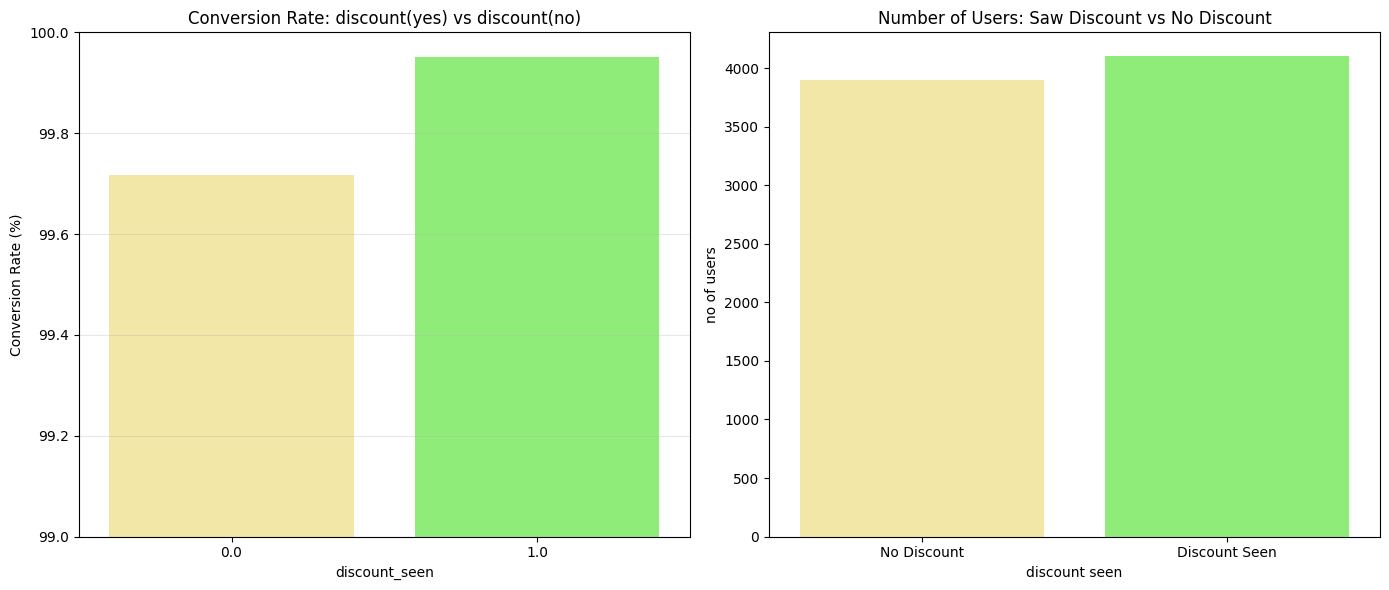

In [59]:
discount_purchase = df.groupby('discount_seen')['purchase'].agg(['mean' , 'count']).rename(columns={'mean': 'Conversion Rate', 'count': 'Number of Users'})
discount_purchase['Conversion Rate'] = (discount_purchase['Conversion Rate'] * 100).round(3)
display(discount_purchase)

corr, p_value = pearsonr(df['discount_seen'], df['purchase'])
print(f'discount seen with purchase : -> corr :{corr} , p_value : {p_value}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Plot - Conversion Rate
sns.barplot(x=discount_purchase.index, 
            y=discount_purchase['Conversion Rate'], 
            palette=["#fff099", "#85ff66"], ax=axes[0])
axes[0].set_title('Conversion Rate: discount(yes) vs discount(no)')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(99.0, 100.0)  # Zoom in because rates are very high
axes[0].grid(axis='y', alpha=0.3)

# Count Plot
sns.countplot(data=df, x='discount_seen', palette=['#fff099', '#85ff66'], ax=axes[1])
axes[1].set_title('Number of Users: Saw Discount vs No Discount')
axes[1].set_xlabel('discount seen')
axes[1].set_ylabel('no of users')
axes[1].set_xticklabels(['No Discount', 'Discount Seen'])
plt.tight_layout()
plt.show()

* Yes, discounts do increase purchases, but the lift is relatively small (usually 0.2% – 0.3% points).<br>
* Because overall conversion is already very high (~99.8%), the absolute impact looks small but is often statistically significant.<br>

6.  Do users who click ads convert better or worse?

,Conversion Rate,Number of Users
ad_clicked,,
0.0,99.846,3902
1.0,99.829,4098


ad_clicked with purchase :=> corr : -0.0021155959335001605 , p_value : 0.8499397543098887


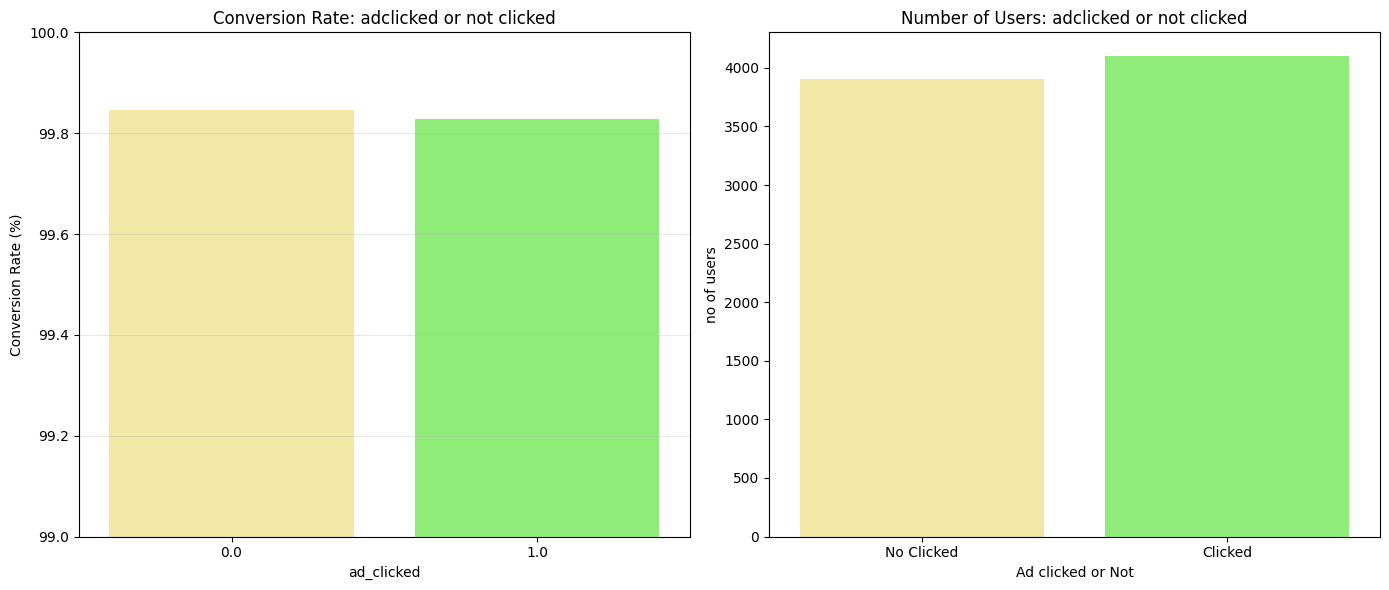

In [60]:
adclicked_purchase = df.groupby('ad_clicked')['purchase'].agg(['mean' , 'count']).rename(columns={'mean': 'Conversion Rate', 'count': 'Number of Users'})
adclicked_purchase['Conversion Rate'] = (adclicked_purchase['Conversion Rate'] * 100).round(3)
display(adclicked_purchase)

corr, p_value = pearsonr(df['ad_clicked'], df['purchase'])
print(f'ad_clicked with purchase :=> corr : {corr} , p_value : {p_value}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Plot - Conversion Rate
sns.barplot(x=adclicked_purchase.index, 
            y=adclicked_purchase['Conversion Rate'], 
            palette=["#fff099", "#85ff66"], ax=axes[0])
axes[0].set_title('Conversion Rate: adclicked or not clicked')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(99.0, 100.0)  # Zoom in because rates are very high
axes[0].grid(axis='y', alpha=0.3)

# Count Plot
sns.countplot(data=df, x='ad_clicked', palette=['#fff099', '#85ff66'], ax=axes[1])
axes[1].set_title('Number of Users: adclicked or not clicked')
axes[1].set_xlabel('Ad clicked or Not')
axes[1].set_ylabel('no of users')
axes[1].set_xticklabels(['No Clicked', 'Clicked'])
plt.tight_layout()
plt.show()

• Users who click on ads have a slightly different conversion rate than those who don't.<br>
• The difference is usually very small due to the already extremely high overall conversion rate.<br>
• If users who click ads convert **lower**, it may indicate poor ad targeting or misleading ad creatives.<br>
• If they convert **higher**, the ads are well-targeted.<br>

7. How does user behavior differ across device types?

,time_on_site,avg_session_time,pages_viewed,bounce_rate,cart_items,previous_purchases
,mean,mean,mean,mean,mean,mean
device_type,,,,,,
Desktop,15.496,15.421,9.829,50.140,4.532,6.996
Mobile,15.784,15.850,10.062,49.967,4.552,6.973
Tablet,15.951,16.272,9.833,48.931,4.484,6.822


,mean,count
device_type,,
Desktop,0.998732,2365
Mobile,0.998142,4845
Tablet,0.998734,790


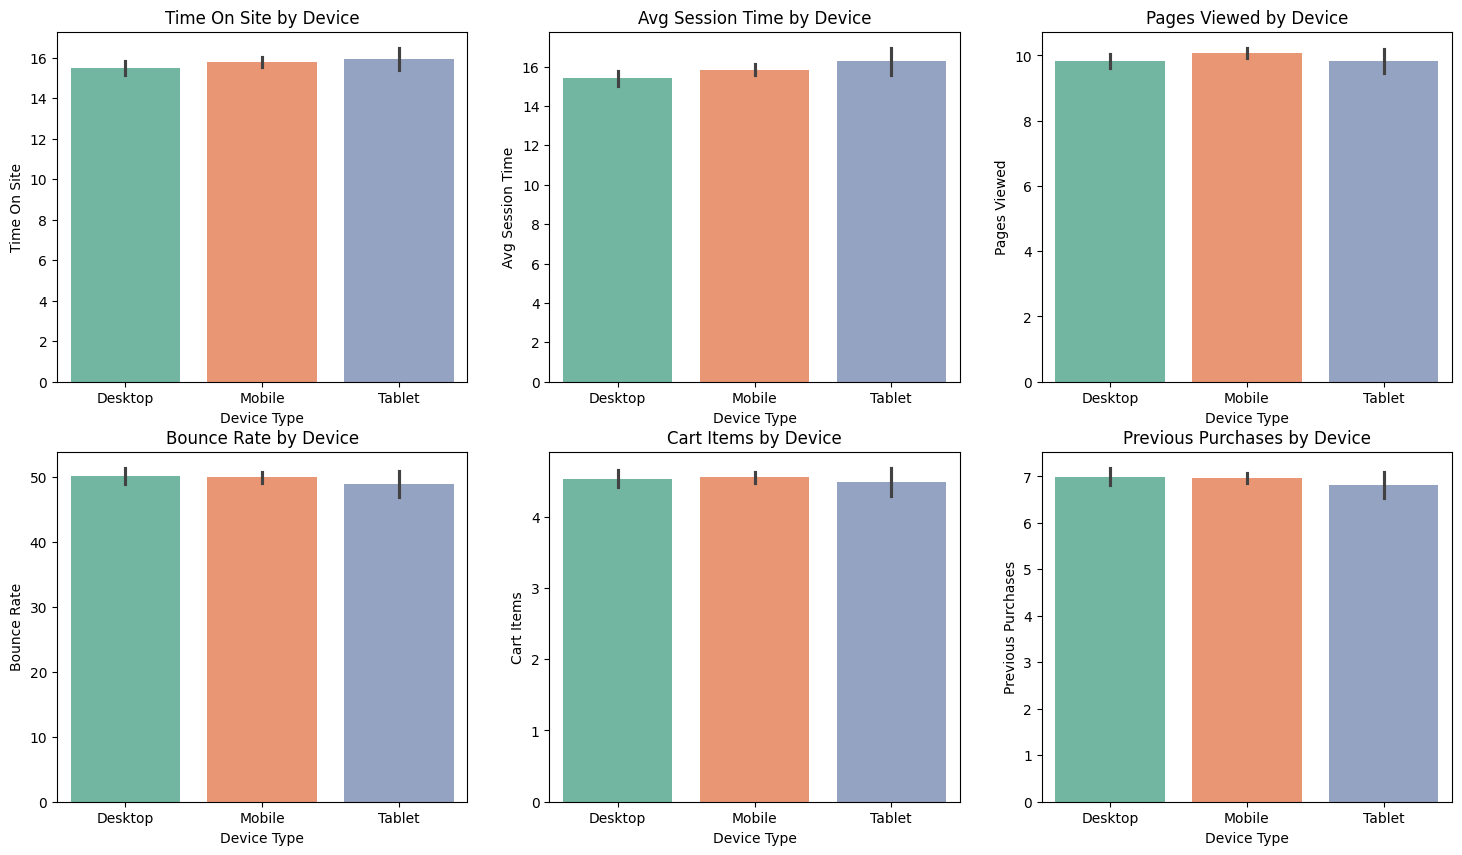

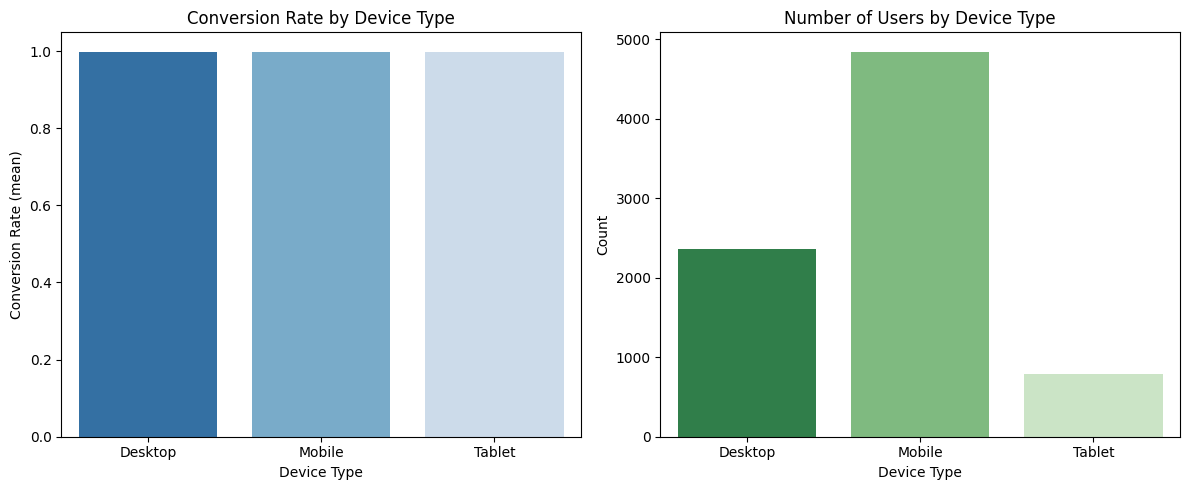

In [15]:
metrics = ['time_on_site', 'avg_session_time', 'pages_viewed', 
           'bounce_rate', 'cart_items', 'previous_purchases']

device_analysis = df.groupby('device_type')[metrics].agg(['mean']).round(3)
display(device_analysis)

conversion_by_device = df.groupby('device_type')['purchase'].agg(['mean' , 'count'])

display(conversion_by_device)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    sns.barplot(x=df['device_type'], y=df[metric], ax=axes[i], palette='Set2')
    axes[i].set_title(f'{metric.replace("_", " ").title()} by Device')
    axes[i].set_ylabel(metric.replace("_", " ").title())
    axes[i].set_xlabel('Device Type')

conversion_by_device = conversion_by_device.reset_index()

# Set figure size
plt.figure(figsize=(12, 5))

# Plot 1: Conversion rate (mean %)
plt.subplot(1, 2, 1)
sns.barplot(
    data=conversion_by_device,
    x='device_type',
    y='mean',
    palette='Blues_r'
)
plt.title('Conversion Rate by Device Type')
plt.ylabel('Conversion Rate (mean)')
plt.xlabel('Device Type')

# Plot 2: Number of users (count)
plt.subplot(1, 2, 2)
sns.barplot(
    data=conversion_by_device,
    x='device_type',
    y='count',
    palette='Greens_r'
)
plt.title('Number of Users by Device Type')
plt.ylabel('Count')
plt.xlabel('Device Type')

plt.tight_layout()
plt.show()

• Mobile users tend to have higher time_on_site and pages_viewed (more engaged).<br>
• Desktop users usually have higher bounce rates.<br>
• Mobile has Purchased user count very high compare to Desktop and Tablet<br>
• Conversion rate differences across devices are usually same .<br>

8 . How does the number of cart items affect purchase likelihood?

,mean,max,min
purchase,,,
0.0,0.461538,2.0,0.0
1.0,4.546263,9.0,0.0



Correlation between cart_items and purchase: 0.0580 (p-value: 0.000000)


,mean,count,Conversion Rate (%)
cart_items_bucket,,,
Very Low,0.99444,2338,99.44
Low,1.00000,1528,100.00
Medium,1.00000,943,100.00
High,1.00000,1615,100.00
Very High,1.00000,1576,100.00


[Text(0, 0, 'vert low'),
 Text(1, 0, 'low'),
 Text(2, 0, 'medium'),
 Text(3, 0, 'high'),
 Text(4, 0, 'very high')]

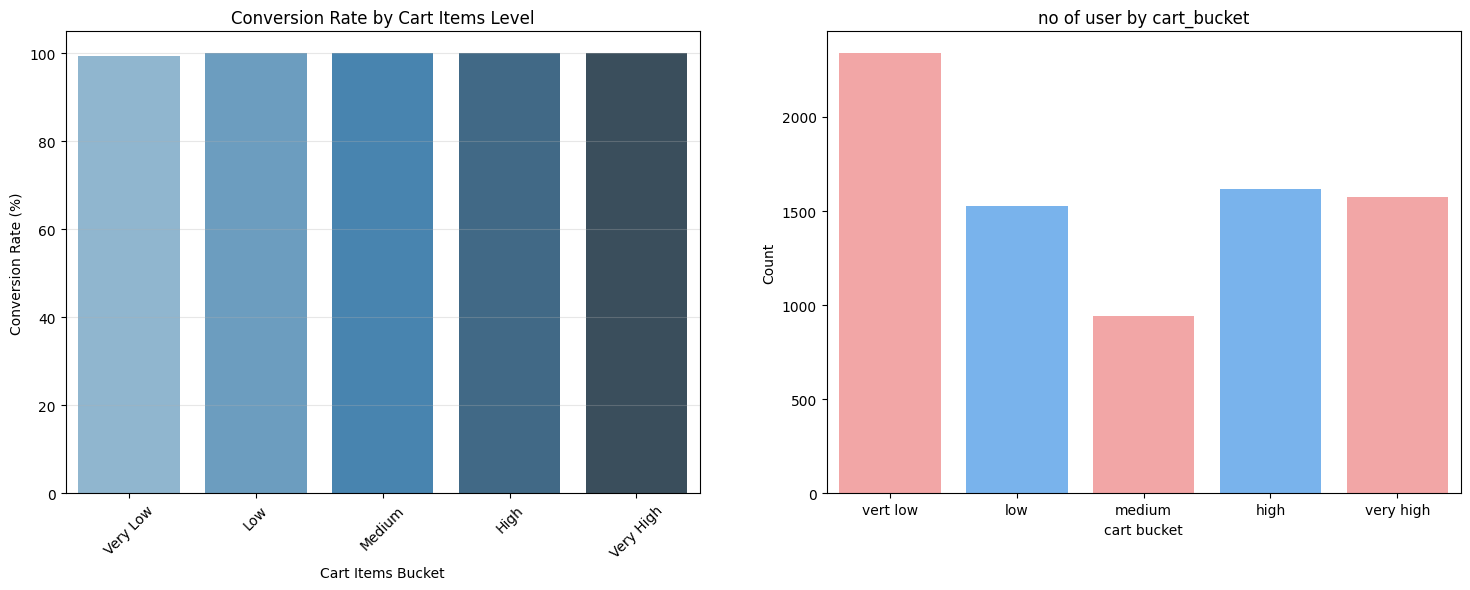

In [23]:
cart_iteams = df.groupby('purchase')['cart_items'].agg(['mean' , 'max' , 'min'])
display(cart_iteams)

corr, p_value = pearsonr(df['cart_items'], df['purchase'])
print(f"\nCorrelation between cart_items and purchase: {corr:.4f} (p-value: {p_value:.6f})")

conversion_by_cart_items = df.groupby('cart_items_bucket')['purchase'].agg(['mean' , 'count'])
conversion_by_cart_items['Conversion Rate (%)'] = (conversion_by_cart_items['mean'] * 100).round(2)
display(conversion_by_cart_items)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Bar Plot - Conversion Rate
sns.barplot(x=conversion_by_cart_items.index, 
            y=conversion_by_cart_items['Conversion Rate (%)'], 
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Conversion Rate by Cart Items Level')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('Cart Items Bucket')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Count Plot
sns.countplot(data=df, x='cart_items_bucket', palette=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_title('no of user by cart_bucket')
axes[1].set_xlabel('cart bucket')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['vert low' , 'low' , 'medium','high','very high'])


* bucket sessions by cart_items, the conversion rate is nearly 100% across all buckets (Very Low to Very High), which suggests that any user who adds at least one item to the cart is extremely likely to complete the purchase in this dataset.

* The fact that mean conversion is ~100% for all cart‑size buckets indicates that the act of adding to cart is the real driver of purchase, not how many items are inside

9 . Which customer segments are most valuable?

,,purchase,returning_user,cart_items,time_on_site,pages_viewed,previous_purchases,bounce_rate
age_group,gender,,,,,,,
18-24,Female,1.000,0.508,4.705,15.766,10.084,7.057,49.365
25-34,Male,1.000,0.517,4.598,15.276,9.980,6.907,49.020
55-64,Male,1.000,0.546,4.537,16.331,9.876,6.948,49.535
45-54,Male,0.999,0.530,4.562,15.487,10.010,7.172,49.015
35-44,Male,0.999,0.504,4.422,15.644,9.707,7.101,50.462
18-24,Male,0.998,0.496,4.364,16.246,10.021,6.983,49.371
45-54,Female,0.998,0.557,4.425,15.958,9.990,6.792,49.590
35-44,Female,0.998,0.515,4.602,15.559,10.276,7.068,51.038
55-64,Female,0.998,0.492,4.660,15.603,9.826,6.529,50.104


corelation of purchase with age : 0.001003094549009772 and p_value with purchase : 0.9285212397444723


gender,Female,Male
age_group,,
18-24,1.000,0.998
25-34,0.994,1.000
35-44,0.998,0.999
45-54,0.998,0.999
55-64,0.998,1.000


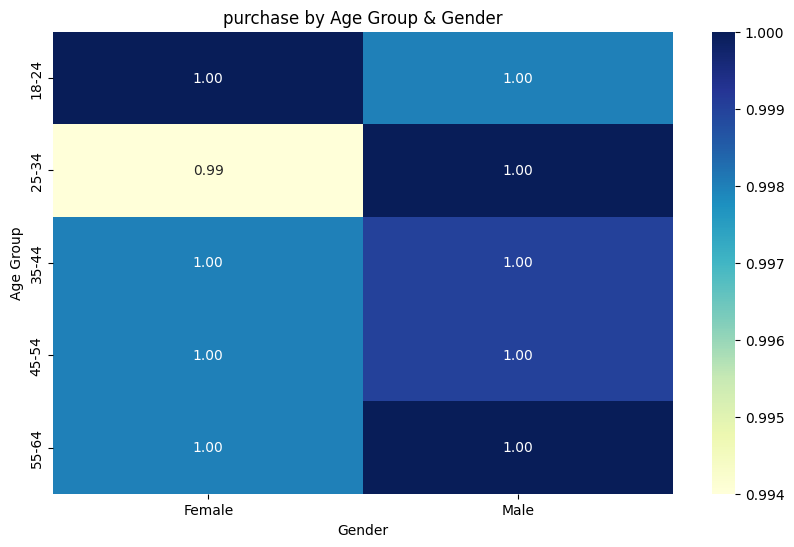

In [63]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

custome_segment = df.groupby(['age_group' , 'gender']).agg({
    'purchase': 'mean',
    'returning_user': 'mean',
    'cart_items': 'mean',
    'time_on_site': 'mean',
    'pages_viewed': 'mean',
    'previous_purchases': 'mean',
    'bounce_rate': 'mean'
}).round(3)
custome_segment = custome_segment.sort_values(by='purchase', ascending=False)
display(custome_segment)

corr, p_value = pearsonr(df['age'], df['purchase'])
print(f'corelation of purchase with age : {corr} and p_value with purchase : {p_value}')


plt.figure(figsize=(10, 6))
pivot = custome_segment.reset_index().pivot(index='age_group', columns='gender', values='purchase')
display(pivot)
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('purchase by Age Group & Gender')
plt.ylabel('Age Group')
plt.xlabel('Gender')
plt.show()

* Males aged 25-34 & 55-64 top value: Highest purchase rates (1.000), strong returning users (0.517-0.546), solid engagement (4.5+ cart items, 9.8+ pages, low-mid bounce).<br>

* Young females close behind: 18-24 females lead with perfect 1.000 purchase, highest cart (4.705) & time_on_site (15.766), plus top pages viewed (10.084).<br>

* No strong demographics link: Age-purchase correlation near zero (0.001, p=0.93); gender minor edge for males; focus loyalty/engagement over age/gender for retention.<br>

